In [27]:
## Decision Tree
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [28]:
from sklearn.datasets import load_iris
iris = load_iris()

In [29]:
print(iris['DESCR'])

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [30]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [31]:
## independent Features
X = pd.DataFrame(iris['data'], columns=['sepal length','sepal width','petal length','petal width'])

In [32]:
y = iris['target']

In [33]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.33,random_state=10)

In [34]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 68 to 9
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  100 non-null    float64
 1   sepal width   100 non-null    float64
 2   petal length  100 non-null    float64
 3   petal width   100 non-null    float64
dtypes: float64(4)
memory usage: 3.9 KB


In [35]:
X_train.columns = X_train.columns.astype(str)
X_test.columns = X_test.columns.astype(str)

In [36]:
## decision tree classifier

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier()

In [37]:
classifier.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
y_pred = classifier.predict(X_test)

In [39]:
from sklearn.metrics import classification_report,accuracy_score
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.9
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.94      0.79      0.86        19
           2       0.79      0.94      0.86        16

    accuracy                           0.90        50
   macro avg       0.91      0.91      0.90        50
weighted avg       0.91      0.90      0.90        50



[Text(0.375, 0.9, 'x[2] <= 2.45\ngini = 0.666\nsamples = 100\nvalue = [35, 31, 34]'),
 Text(0.25, 0.7, 'gini = 0.0\nsamples = 35\nvalue = [35, 0, 0]'),
 Text(0.3125, 0.8, 'True  '),
 Text(0.5, 0.7, 'x[2] <= 4.75\ngini = 0.499\nsamples = 65\nvalue = [0, 31, 34]'),
 Text(0.4375, 0.8, '  False'),
 Text(0.25, 0.5, 'x[3] <= 1.6\ngini = 0.064\nsamples = 30\nvalue = [0, 29, 1]'),
 Text(0.125, 0.3, 'gini = 0.0\nsamples = 29\nvalue = [0, 29, 0]'),
 Text(0.375, 0.3, 'gini = 0.0\nsamples = 1\nvalue = [0, 0, 1]'),
 Text(0.75, 0.5, 'x[3] <= 1.75\ngini = 0.108\nsamples = 35\nvalue = [0, 2, 33]'),
 Text(0.625, 0.3, 'x[3] <= 1.55\ngini = 0.48\nsamples = 5\nvalue = [0, 2, 3]'),
 Text(0.5, 0.1, 'gini = 0.0\nsamples = 3\nvalue = [0, 0, 3]'),
 Text(0.75, 0.1, 'gini = 0.0\nsamples = 2\nvalue = [0, 2, 0]'),
 Text(0.875, 0.3, 'gini = 0.0\nsamples = 30\nvalue = [0, 0, 30]')]

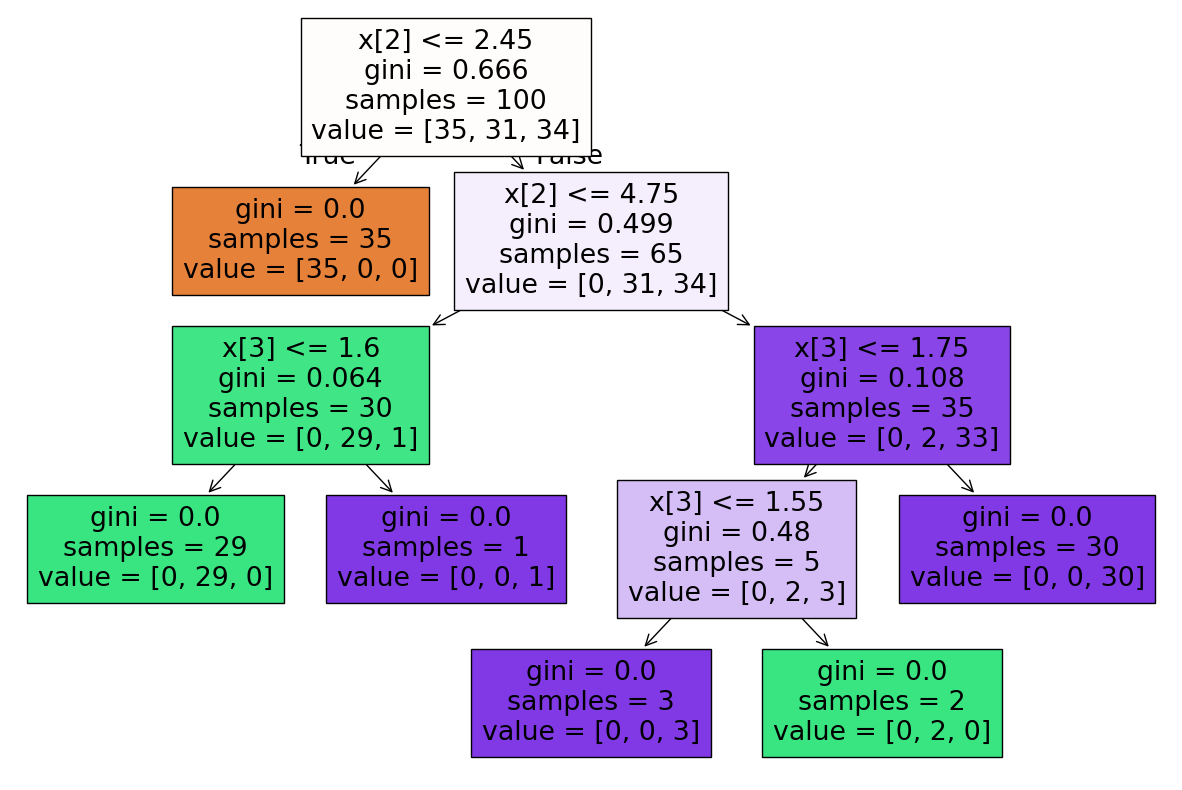

In [40]:
## visualize
from sklearn import tree
plt.figure(figsize=(15,10))
tree.plot_tree(classifier,filled=True)

In [41]:
## prunning and hyperparameter tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'criterion':['gini', 'entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth': [1,2,3,4,5],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [42]:
from sklearn.tree import DecisionTreeClassifier
treemodel = DecisionTreeClassifier()
grid = GridSearchCV(treemodel,param_grid=param_grid,scoring='accuracy',cv=5)

In [43]:
grid.fit(X_train,y_train)

c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
150 fits failed out of a total of 450.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
150 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\base.py"

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [44]:
y_pred = grid.predict(X_test)

In [45]:
grid.best_params_

{'criterion': 'entropy',
 'max_depth': 3,
 'max_features': 'log2',
 'splitter': 'best'}

In [46]:
grid.best_score_

np.float64(0.97)

In [47]:
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[15  0  0]
 [ 0 18  1]
 [ 0  1 15]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.95      0.95      0.95        19
           2       0.94      0.94      0.94        16

    accuracy                           0.96        50
   macro avg       0.96      0.96      0.96        50
weighted avg       0.96      0.96      0.96        50



## Decision Tree Regressor

In [48]:
from sklearn.datasets import load_diabetes
df = load_diabetes()

In [49]:
print(df['DESCR'])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [50]:
import pandas as pd

In [51]:
df_diabetes = pd.DataFrame(df.data, columns=['age','sex','bmi','bp','s1','s2','s3','s4','s5','s6'])

In [52]:
## independent and dependent features

X = df_diabetes
y = df.target

In [53]:
X.head(), y

(        age       sex       bmi  ...        s4        s5        s6
 0  0.038076  0.050680  0.061696  ... -0.002592  0.019907 -0.017646
 1 -0.001882 -0.044642 -0.051474  ... -0.039493 -0.068332 -0.092204
 2  0.085299  0.050680  0.044451  ... -0.002592  0.002861 -0.025930
 3 -0.089063 -0.044642 -0.011595  ...  0.034309  0.022688 -0.009362
 4  0.005383 -0.044642 -0.036385  ... -0.002592 -0.031988 -0.046641
 
 [5 rows x 10 columns],
 array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59., 104., 182.,
        128.,  52.,  37., 170., 170.,  61., 144.,  52., 128.,  71., 163.,
        150.,  97., 160., 178.,  48., 270., 202., 111.,  85.,  42., 170.,
        200., 252., 113., 143.,  51.,  52., 210.

In [54]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.33,random_state=42)

In [55]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor()
regressor.fit(X_train,y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


<Axes: >

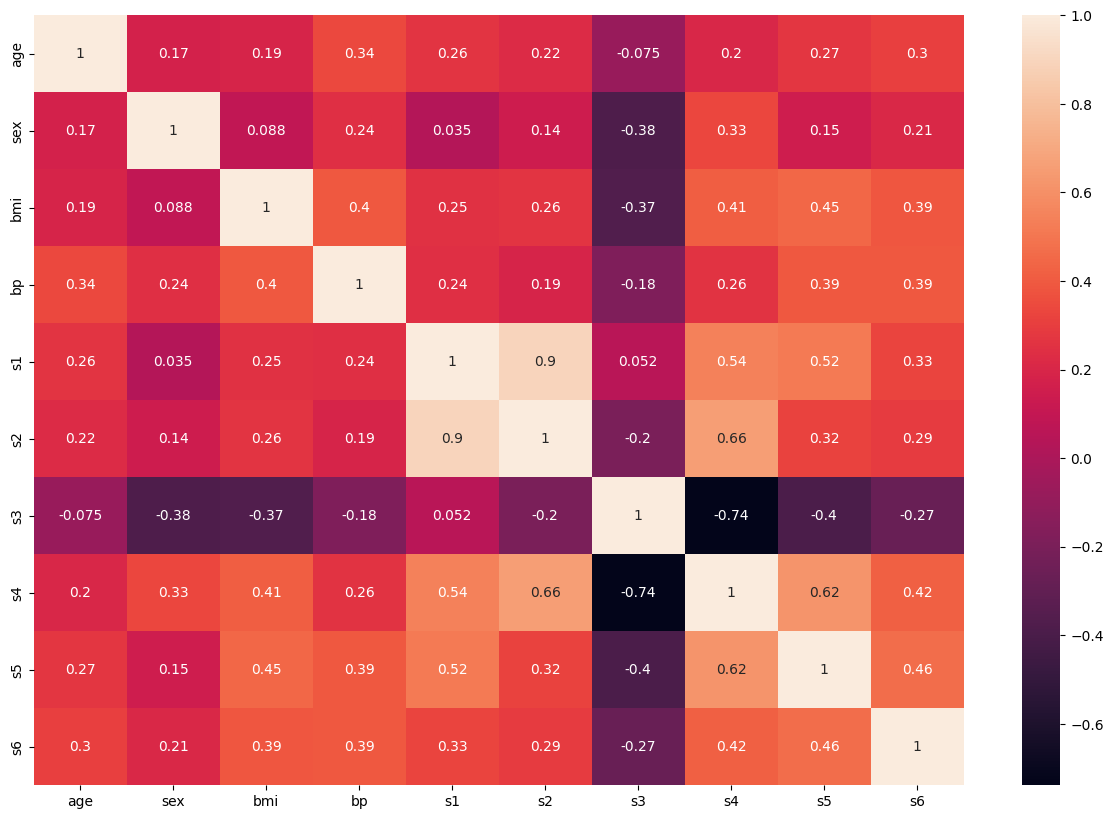

In [56]:
## heatmap to visualize corr
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(15,10))
sns.heatmap(X.corr(),annot=True)

In [57]:
## Hyperparameter Tuning

from sklearn.model_selection import GridSearchCV

param = {
    'criterion': ['squared_error', 'friedman_mse', 'absolute_error', ],
    'splitter': ['best','random'],
    'max_depth': [1,2,3,4,5,10,15,20,25],
    'max_features': ['auto', 'sqrt', 'log2']
}

In [58]:
from sklearn.tree import DecisionTreeRegressor

treemodel = DecisionTreeRegressor()
grid = GridSearchCV(treemodel,param_grid=param,cv=5,scoring='accuracy',n_jobs=-1)

In [59]:
grid.fit(X_train,y_train)

c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
270 fits failed out of a total of 810.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
141 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\base.py", line 1358, in wrapper
    estimator._validate_params()
  File "c:\Users\91620\OneDrive\Desktop\Data_science_pra\venv\Lib\site-packages\sklearn\base.py"

,estimator,DecisionTreeRegressor()
,param_grid,"{'criterion': ['squared_error', 'friedman_mse', ...], 'max_depth': [1, 2, ...], 'max_features': ['auto', 'sqrt', ...], 'splitter': ['best', 'random']}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'absolute_error'


In [60]:
grid.best_params_

{'criterion': 'absolute_error',
 'max_depth': 20,
 'max_features': 'log2',
 'splitter': 'random'}

In [61]:
grid.best_score_

np.float64(0.020112994350282486)

In [62]:
y_pred = grid.predict(X_test)
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))
print(mean_squared_error(y_test,y_pred))

-0.030909253343193166
61.71232876712329
5933.1506849315065


In [63]:
selectedmodel=DecisionTreeRegressor(criterion='absolute_error',max_depth=25,max_features='log2',splitter='best')
selectedmodel.fit(X_train,y_train)

,criterion,'absolute_error'
,splitter,'best'
,max_depth,25
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'log2'
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


[Text(0.6393318965517242, 0.9782608695652174, 'x[2] <= 0.009\nabsolute_error = 64.78\nsamples = 296\nvalue = 141.5'),
 Text(0.4469673645320197, 0.9347826086956522, 'x[5] <= 0.032\nabsolute_error = 49.674\nsamples = 187\nvalue = 104.0'),
 Text(0.5431496305418719, 0.9565217391304348, 'True  '),
 Text(0.3058805418719212, 0.8913043478260869, 'x[8] <= 0.022\nabsolute_error = 47.625\nsamples = 152\nvalue = 96.5'),
 Text(0.1477216748768473, 0.8478260869565217, 'x[6] <= -0.019\nabsolute_error = 41.887\nsamples = 133\nvalue = 88.0'),
 Text(0.034482758620689655, 0.8043478260869565, 'x[4] <= -0.052\nabsolute_error = 56.13\nsamples = 23\nvalue = 124.0'),
 Text(0.015763546798029555, 0.7608695652173914, 'x[4] <= -0.057\nabsolute_error = 31.5\nsamples = 6\nvalue = 180.0'),
 Text(0.011822660098522168, 0.717391304347826, 'x[4] <= -0.065\nabsolute_error = 23.0\nsamples = 5\nvalue = 178.0'),
 Text(0.007881773399014778, 0.6739130434782609, 'x[4] <= -0.082\nabsolute_error = 15.25\nsamples = 4\nvalue = 180.

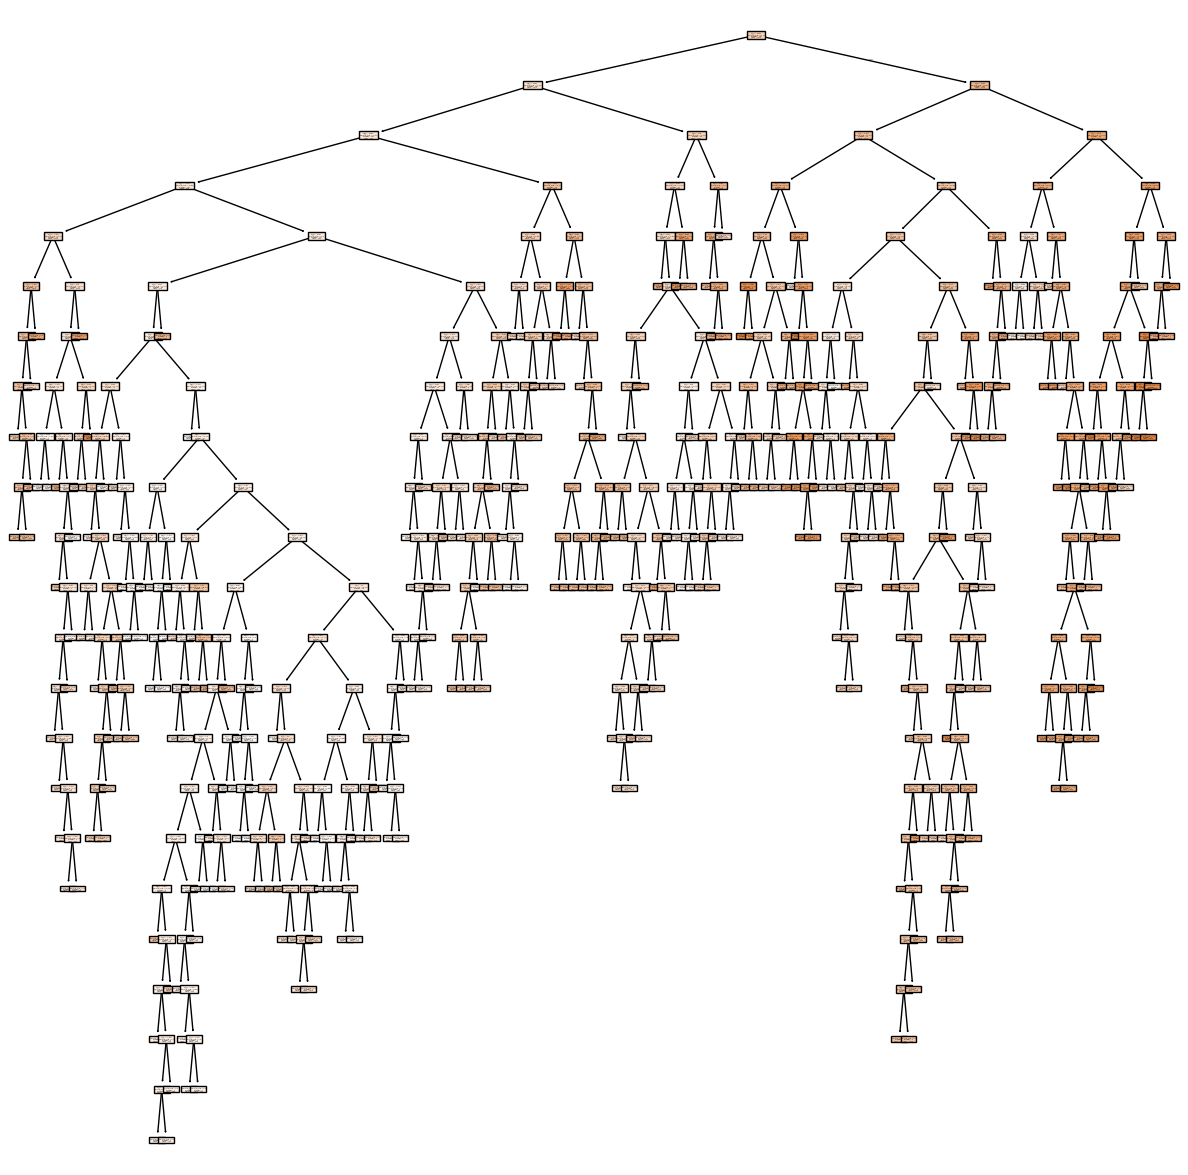

In [65]:
plt.figure(figsize=(15,15))
tree.plot_tree(selectedmodel,filled=True)